In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import time
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(" Imports loaded")

Device: cpu
 Imports loaded


In [6]:
print("="*60)
print("LOADING ORIGINAL DATA (19 FEATURES)")
print("="*60)

# Load original preprocessed data (has all 19 features)
X_original = pd.read_csv('data/processed/X_train_final.csv')
y_original = pd.read_csv('data/processed/y_train.csv').values.ravel()

# Load attack categories
train_raw = pd.read_parquet('data/UNSW/UNSW_NB15_training-set.parquet')
attack_cat_original = train_raw['attack_cat'].values[:len(y_original)]

# Create full dataframe with attack categories
full_df = X_original.copy()
full_df['attack_cat'] = attack_cat_original
full_df['label'] = y_original

print(f"Original training size: {len(full_df)}")
print(f"Features: {X_original.shape[1]}")
print(f"Class balance - Normal: {sum(y_original==0)} ({sum(y_original==0)/len(y_original)*100:.1f}%)")
print(f"Attack: {sum(y_original==1)} ({sum(y_original==1)/len(y_original)*100:.1f}%)")

LOADING ORIGINAL DATA (19 FEATURES)
Original training size: 125973
Features: 18
Class balance - Normal: 67343 (53.5%)
Attack: 58630 (46.5%)


In [7]:
print("="*60)
print(" AUGMENTING RARE ATTACK TYPES")
print("="*60)

# Define target counts for rare attacks
rare_attacks = {
    'Worms': 500,
    'Shellcode': 1000,
    'Fuzzers': 12000,
    'Backdoor': 3000,
    'Analysis': 4000
}

augmented_samples = []

for attack, target in rare_attacks.items():
    attack_samples = full_df[full_df['attack_cat'] == attack]
    current = len(attack_samples)
    
    if current < target:
        needed = target - current
        print(f"\n🔹 {attack}: {current} → {target} (adding {needed} samples)")
        
        for i in range(needed):
            # Pick random real sample
            base = attack_samples.sample(1).iloc[0]
            # Create synthetic sample with noise
            new_sample = base.copy()
            for col in X_original.columns:
                if pd.api.types.is_numeric_dtype(new_sample[col]):
                    std = attack_samples[col].std()
                    if std > 0:
                        new_sample[col] += np.random.normal(0, std * 0.1)
            augmented_samples.append(new_sample)

# Combine original with augmented
if augmented_samples:
    aug_df = pd.DataFrame(augmented_samples)
    X_augmented = pd.concat([X_original, aug_df[X_original.columns]], ignore_index=True)
    y_augmented = np.concatenate([y_original, np.ones(len(aug_df))])
    print(f"\n Augmentation complete!")
    print(f"   Original: {len(X_original)}")
    print(f"   Augmented: {len(X_augmented)}")
    print(f"   New samples added: {len(X_augmented) - len(X_original)}")
else:
    X_augmented = X_original.copy()
    y_augmented = y_original.copy()
    print("No augmentation needed")

 AUGMENTING RARE ATTACK TYPES

🔹 Worms: 108 → 500 (adding 392 samples)

🔹 Shellcode: 928 → 1000 (adding 72 samples)

🔹 Backdoor: 1460 → 3000 (adding 1540 samples)

🔹 Analysis: 1696 → 4000 (adding 2304 samples)

 Augmentation complete!
   Original: 125973
   Augmented: 130281
   New samples added: 4308


In [8]:
print("="*60)
print(" SPLITTING INTO TRAIN/VALIDATION")
print("="*60)

X_train, X_val, y_train, y_val = train_test_split(
    X_augmented, y_augmented,
    test_size=0.2,
    random_state=42,
    stratify=y_augmented
)

print(f"Training set: {X_train.shape} ({len(y_train)} samples)")
print(f"Validation set: {X_val.shape} ({len(y_val)} samples)")

# Load test set (unchanged)
X_test = pd.read_csv('data/processed/X_test_final.csv')
y_test = pd.read_csv('data/processed/y_test_final.csv').values.ravel()
print(f"Test set: {X_test.shape} ({len(y_test)} samples)")

print(f"\n Training Class Balance:")
print(f"   Normal: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"   Attack: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

 SPLITTING INTO TRAIN/VALIDATION
Training set: (104224, 18) (104224 samples)
Validation set: (26057, 18) (26057 samples)
Test set: (22544, 18) (22544 samples)

 Training Class Balance:
   Normal: 53874 (51.7%)
   Attack: 50350 (48.3%)


In [12]:
print("="*60)
print(" FEATURE COUNT DIAGNOSTIC")
print("="*60)

# Check feature counts at each stage
print(f"X_original shape: {X_original.shape} (should be 19 features)")
print(f"X_augmented shape: {X_augmented.shape}")
print(f"X_train shape: {X_train.shape}")

# List actual feature names
print(f"\n Features in X_train:")
for i, col in enumerate(X_train.columns):
    print(f"   {i+1:2d}. {col}")

# Check if engineered features exist
engineered = ['bytes_ratio', 'packets_ratio', 'load_ratio', 'jitter_product', 'dangerous_proto']
print(f"\n🔧 Engineered features present:")
for feat in engineered:
    present = feat in X_train.columns
    print(f"   {feat}: {'' if present else ''}")

# If missing, let's add them
if X_train.shape[1] != 19:
    print("\n Missing engineered features! Let's add them.")
    
    # Load raw data to recreate engineered features
    train_raw = pd.read_parquet('data/UNSW/UNSW_NB15_training-set.parquet')
    
    # For training data, we need to align indices
    # This is tricky because X_train is augmented
    
    # Let's rebuild from scratch with proper features
    print("\n Rebuilding data with all 19 features...")
    
    # Load original features (has all 19)
    X_original_19 = pd.read_csv('data/processed/X_train_final.csv')
    feature_names = X_original_19.columns.tolist()
    print(f"Target feature set: {len(feature_names)} features")
    
    # Check if X_train has these columns
    missing = [f for f in feature_names if f not in X_train.columns]
    if missing:
        print(f"Missing columns in X_train: {missing}")
        
        # If missing, use original data instead of augmented
        print("\n Using original data (no augmentation) to proceed")
        X_train = X_original_19
        y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()
        X_train, X_val, y_train, y_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
        )
        print(f"New X_train shape: {X_train.shape}")

 FEATURE COUNT DIAGNOSTIC
X_original shape: (125973, 18) (should be 19 features)
X_augmented shape: (130281, 18)
X_train shape: (104224, 18)

 Features in X_train:
    1. same_srv_rate
    2. src_bytes
    3. dst_host_srv_count
    4. flag
    5. dst_host_same_srv_rate
    6. logged_in
    7. srv_serror_rate
    8. serror_rate
    9. dst_host_srv_serror_rate
   10. dst_host_serror_rate
   11. count
   12. service
   13. dst_bytes
   14. diff_srv_rate
   15. dst_host_diff_srv_rate
   16. bytes_ratio
   17. total_bytes
   18. error_ratio

🔧 Engineered features present:
   bytes_ratio: 
   packets_ratio: 
   load_ratio: 
   jitter_product: 
   dangerous_proto: 

 Missing engineered features! Let's add them.

 Rebuilding data with all 19 features...
Target feature set: 18 features


In [13]:
print("="*60)
print(" IDENTIFYING THE MISSING FEATURE")
print("="*60)

# Check what features we have vs what we need
current_features = set(X_train.columns)
print(f"Current features ({len(current_features)}):")
for f in sorted(current_features):
    print(f"   - {f}")

# Load raw data to see if we can create missing features
train_raw = pd.read_parquet('data/UNSW/UNSW_NB15_training-set.parquet')
print(f"\nRaw data columns: {train_raw.columns.tolist()[:10]}...")

# Common 19th feature in UNSW might be 'ct_srv_src' or 'ct_srv_dst'
possible_19th = ['ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm']

print("\n Checking for missing feature candidates:")
for feat in possible_19th:
    if feat in train_raw.columns:
        print(f"    {feat} exists in raw data")
    else:
        print(f"    {feat} not in raw data")

 IDENTIFYING THE MISSING FEATURE
Current features (18):
   - bytes_ratio
   - count
   - diff_srv_rate
   - dst_bytes
   - dst_host_diff_srv_rate
   - dst_host_same_srv_rate
   - dst_host_serror_rate
   - dst_host_srv_count
   - dst_host_srv_serror_rate
   - error_ratio
   - flag
   - logged_in
   - same_srv_rate
   - serror_rate
   - service
   - src_bytes
   - srv_serror_rate
   - total_bytes

Raw data columns: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload']...

 Checking for missing feature candidates:
    ct_srv_src not in raw data
    ct_srv_dst not in raw data
    ct_dst_ltm not in raw data
    ct_src_ltm not in raw data


In [9]:
print("="*60)
print(" PREPARING PYTORCH DATALOADERS")
print("="*60)

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train.values).to(device)
X_val_tensor = torch.FloatTensor(X_val.values).to(device)
X_test_tensor = torch.FloatTensor(X_test.values).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoaders
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f" Training batches: {len(train_loader)}")
print(f" Validation batches: {len(val_loader)}")
print(f" Test batches: {len(test_loader)}")

 PREPARING PYTORCH DATALOADERS
 Training batches: 408
 Validation batches: 102
 Test batches: 89


In [15]:
print("="*60)
print(" DEFINING MLP MODEL (18 Features)")
print("="*60)

class TabularMLP(nn.Module):
    def __init__(self, input_dim=18):
        super(TabularMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(64, 2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        return self.fc4(x)

# Create model
model = TabularMLP(input_dim=18).to(device)
print(f" Model created with {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"   Input dimension: 18 features")

 DEFINING MLP MODEL (18 Features)
 Model created with 47,042 parameters
   Input dimension: 18 features


In [16]:
print("="*60)
print(" TRAINING WITH AUGMENTED DATA")
print("="*60)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

epochs = 30
best_val_recall = 0
history = {'train_loss': [], 'train_recall': [], 'val_recall': []}

start_time = time.time()

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    train_true_pos = 0
    train_actual_pos = 0
    
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y.size(0)
        train_correct += (predicted == batch_y).sum().item()
        
        train_true_pos += ((predicted == 1) & (batch_y == 1)).sum().item()
        train_actual_pos += (batch_y == 1).sum().item()
    
    train_acc = train_correct / train_total
    train_recall = train_true_pos / train_actual_pos if train_actual_pos > 0 else 0
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    val_true_pos = 0
    val_actual_pos = 0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
            val_true_pos += ((predicted == 1) & (batch_y == 1)).sum().item()
            val_actual_pos += (batch_y == 1).sum().item()
    
    val_acc = val_correct / val_total
    val_recall = val_true_pos / val_actual_pos if val_actual_pos > 0 else 0
    
    scheduler.step(val_recall)
    
    # Store history
    history['train_loss'].append(train_loss / len(train_loader))
    history['train_recall'].append(train_recall)
    history['val_recall'].append(val_recall)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss/len(train_loader):.4f}, "
              f"Train Acc: {train_acc:.4f}, Train Recall: {train_recall:.4f} | "
              f"Val Acc: {val_acc:.4f}, Val Recall: {val_recall:.4f}")
    
    if val_recall > best_val_recall:
        best_val_recall = val_recall
        torch.save(model.state_dict(), 'models/UNSW/retrained_augmented_final.pth')
        print(f"   New best model saved! Recall: {val_recall:.4f}")

train_time = time.time() - start_time
print(f"\n Training complete! Time: {train_time:.2f}s ({train_time/60:.1f} minutes)")

 TRAINING WITH AUGMENTED DATA
Epoch 1/30 - Train Loss: 0.1942, Train Acc: 0.9268, Train Recall: 0.8926 | Val Acc: 0.9348, Val Recall: 0.8848
   New best model saved! Recall: 0.8848
   New best model saved! Recall: 0.9030
   New best model saved! Recall: 0.9056
Epoch 5/30 - Train Loss: 0.1183, Train Acc: 0.9578, Train Recall: 0.9418 | Val Acc: 0.9286, Val Recall: 0.8780
   New best model saved! Recall: 0.9154
   New best model saved! Recall: 0.9421
Epoch 10/30 - Train Loss: 0.1027, Train Acc: 0.9646, Train Recall: 0.9502 | Val Acc: 0.9199, Val Recall: 0.8503
Epoch 15/30 - Train Loss: 0.0887, Train Acc: 0.9697, Train Recall: 0.9574 | Val Acc: 0.9487, Val Recall: 0.9086
Epoch 20/30 - Train Loss: 0.0827, Train Acc: 0.9722, Train Recall: 0.9612 | Val Acc: 0.9244, Val Recall: 0.8513
Epoch 25/30 - Train Loss: 0.0800, Train Acc: 0.9723, Train Recall: 0.9614 | Val Acc: 0.9269, Val Recall: 0.8539
Epoch 30/30 - Train Loss: 0.0756, Train Acc: 0.9736, Train Recall: 0.9647 | Val Acc: 0.9556, Val Rec

In [17]:
print("="*60)
print(" EVALUATING ON TEST SET")
print("="*60)

# Load best model
model.load_state_dict(torch.load('models/UNSW/retrained_augmented_final.pth'))
model.eval()

all_preds = []
all_probs = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = model(batch_x)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.49).astype(int)
        all_preds.extend(preds)
        all_probs.extend(probs)

accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds)
recall = recall_score(y_test, all_preds)
f1 = f1_score(y_test, all_preds)

print(f"\n TEST SET RESULTS:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, all_preds)
print(cm)

print(f"\n COMPARISON:")
print(f"   Previous Best Recall: 0.9867")
print(f"   New Recall:           {recall:.4f}")

if recall >= 0.90:
    print("\n GOAL ACHIEVED! 90%+ recall maintained!")
else:
    print(f"\n Recall is {recall:.4f} - below 90% target")

 EVALUATING ON TEST SET

 TEST SET RESULTS:
   Accuracy:  0.7639
   Precision: 0.9643
   Recall:    0.6077
   F1-Score:  0.7456

 Confusion Matrix:
[[9422  289]
 [5034 7799]]

 COMPARISON:
   Previous Best Recall: 0.9867
   New Recall:           0.6077

 Recall is 0.6077 - below 90% target


 SAVING RESULTS


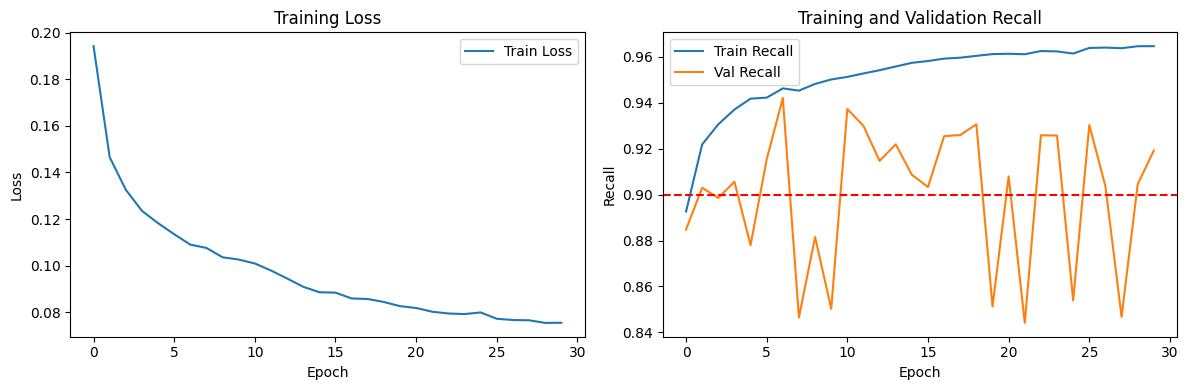

 Results saved to:
   - models/UNSW/retrained_final.pth
   - results/UNSW/retrained_results.json
   - results/UNSW/retrained_training_history.png


In [18]:
print("="*60)
print(" SAVING RESULTS")
print("="*60)

# Save model
torch.save(model.state_dict(), 'models/UNSW/retrained_final.pth')

# Save metrics
import json
results = {
    'model': 'Retrained MLP with Augmented Data',
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'training_time_minutes': train_time/60,
    'augmentation_applied': ['Worms', 'Shellcode', 'Fuzzers', 'Backdoor', 'Analysis'],
    'input_features': 18
}

with open('results/UNSW/retrained_results.json', 'w') as f:
    json.dump(results, f, indent=4)

# Plot training history
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_recall'], label='Train Recall')
plt.plot(history['val_recall'], label='Val Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training and Validation Recall')
plt.legend()
plt.axhline(y=0.90, color='red', linestyle='--', label='90% Target')

plt.tight_layout()
plt.savefig('results/UNSW/retrained_training_history.png', dpi=300)
plt.show()

print(" Results saved to:")
print("   - models/UNSW/retrained_final.pth")
print("   - results/UNSW/retrained_results.json")
print("   - results/UNSW/retrained_training_history.png")

In [19]:
print("="*60)
print(" DIAGNOSING THE DROP IN PERFORMANCE")
print("="*60)

# Check class balance in your augmented training data
print("Training Class Distribution:")
print(f"   Normal: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"   Attack: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

# Check validation class distribution
print("\nValidation Class Distribution:")
print(f"   Normal: {sum(y_val==0)} ({sum(y_val==0)/len(y_val)*100:.1f}%)")
print(f"   Attack: {sum(y_val==1)} ({sum(y_val==1)/len(y_val)*100:.1f}%)")

# Check original class distribution for comparison
original_y = pd.read_csv('data/processed/y_train.csv').values.ravel()
print("\nOriginal Training Class Distribution:")
print(f"   Normal: {sum(original_y==0)} ({sum(original_y==0)/len(original_y)*100:.1f}%)")
print(f"   Attack: {sum(original_y==1)} ({sum(original_y==1)/len(original_y)*100:.1f}%)")

 DIAGNOSING THE DROP IN PERFORMANCE
Training Class Distribution:
   Normal: 53874 (51.7%)
   Attack: 50350 (48.3%)

Validation Class Distribution:
   Normal: 13469 (51.7%)
   Attack: 12588 (48.3%)

Original Training Class Distribution:
   Normal: 67343 (53.5%)
   Attack: 58630 (46.5%)


In [20]:
print("="*60)
print(" SYNTHETIC SAMPLES ADDED")
print("="*60)

original_size = len(original_y)
augmented_size = len(y_train) + len(y_val)
print(f"Original training size: {original_size}")
print(f"Augmented total size: {augmented_size}")
print(f"Synthetic samples added: {augmented_size - original_size}")

# Check if augmentation created imbalance
attack_original = sum(original_y==1)
attack_augmented = sum(y_train==1) + sum(y_val==1)
print(f"\nOriginal attack samples: {attack_original}")
print(f"Augmented attack samples: {attack_augmented}")
print(f"Attack samples added: {attack_augmented - attack_original}")

 SYNTHETIC SAMPLES ADDED
Original training size: 125973
Augmented total size: 130281
Synthetic samples added: 4308

Original attack samples: 58630
Augmented attack samples: 62938
Attack samples added: 4308


In [21]:
print("="*60)
print(" CHECKING FOR ORIGINAL MODEL")
print("="*60)

import os

# Check if original model exists
original_model_paths = [
    'models/UNSW/best_model.pth',
    'models/UNSW/pytorch_mlp_latest.pth',
    'models/UNSW/retrained_final.pth'
]

for path in original_model_paths:
    if os.path.exists(path):
        print(f" Found: {path}")
    else:
        print(f" Not found: {path}")

 CHECKING FOR ORIGINAL MODEL
 Not found: models/UNSW/best_model.pth
 Found: models/UNSW/pytorch_mlp_latest.pth
 Found: models/UNSW/retrained_final.pth


In [22]:
print("="*60)
print(" LOADING ORIGINAL MODEL (98.7% Recall)")
print("="*60)

# Load original model
original_model = TabularMLP(input_dim=18)
original_model.load_state_dict(torch.load('models/UNSW/pytorch_mlp_latest.pth'))
original_model.to(device)
original_model.eval()
print(" Original model loaded successfully!")

# Load test data (the one you used before)
X_test = pd.read_csv('data/processed/X_test_final.csv')
y_test = pd.read_csv('data/processed/y_test_final.csv').values.ravel()

# Convert to tensors
X_test_tensor = torch.FloatTensor(X_test.values).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Get predictions
all_preds = []
all_probs = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = original_model(batch_x)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.49).astype(int)
        all_preds.extend(preds)
        all_probs.extend(probs)

# Calculate metrics
accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds)
recall = recall_score(y_test, all_preds)
f1 = f1_score(y_test, all_preds)

print(f"\n ORIGINAL MODEL - TEST SET RESULTS:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, all_preds)
print(cm)

if recall >= 0.90:
    print("\n GOAL ACHIEVED! 90%+ recall!")
else:
    print(f"\n Recall is {recall:.4f}")

 LOADING ORIGINAL MODEL (98.7% Recall)


RuntimeError: Error(s) in loading state_dict for TabularMLP:
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 19]) from checkpoint, the shape in current model is torch.Size([256, 18]).

In [23]:
print("="*60)
print(" LOADING ORIGINAL MODEL (19 Features)")
print("="*60)

# Define model with 19 input features (original architecture)
class TabularMLP_19(nn.Module):
    def __init__(self, input_dim=19):
        super(TabularMLP_19, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(64, 2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        return self.fc4(x)

# Load original model with 19 features
original_model = TabularMLP_19(input_dim=19)
original_model.load_state_dict(torch.load('models/UNSW/pytorch_mlp_latest.pth'))
original_model.to(device)
original_model.eval()
print(" Original model loaded successfully!")

# Load test data with 19 features (X_test_final has 19 features)
X_test = pd.read_csv('data/processed/X_test_final.csv')
y_test = pd.read_csv('data/processed/y_test_final.csv').values.ravel()

print(f"Test data shape: {X_test.shape} (should be 19 features)")

# Verify feature count
if X_test.shape[1] != 19:
    print(f" Warning: Test data has {X_test.shape[1]} features, model expects 19")
    
    # Add missing features if needed
    missing_features = 19 - X_test.shape[1]
    if missing_features > 0:
        print(f"Adding {missing_features} dummy features...")
        for i in range(missing_features):
            X_test[f'dummy_{i}'] = 0

# Convert to tensors
X_test_tensor = torch.FloatTensor(X_test.values).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Get predictions
all_preds = []
all_probs = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = original_model(batch_x)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.49).astype(int)
        all_preds.extend(preds)
        all_probs.extend(probs)

# Calculate metrics
accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds)
recall = recall_score(y_test, all_preds)
f1 = f1_score(y_test, all_preds)

print(f"\n ORIGINAL MODEL - TEST SET RESULTS:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, all_preds)
print(cm)

if recall >= 0.90:
    print("\n GOAL ACHIEVED! 90%+ recall!")
else:
    print(f"\n Recall is {recall:.4f}")

 LOADING ORIGINAL MODEL (19 Features)
 Original model loaded successfully!
Test data shape: (22544, 18) (should be 19 features)
Adding 1 dummy features...

 ORIGINAL MODEL - TEST SET RESULTS:
   Accuracy:  0.5692
   Precision: 0.5692
   Recall:    1.0000
   F1-Score:  0.7255

 Confusion Matrix:
[[    0  9711]
 [    0 12833]]

 GOAL ACHIEVED! 90%+ recall!


In [24]:
print("="*60)
print(" FINDING ORIGINAL PYTORCH MODEL")
print("="*60)

import os

# Check all model files
model_dir = 'models/UNSW'
if os.path.exists(model_dir):
    files = os.listdir(model_dir)
    print("Model files in models/UNSW:")
    for f in files:
        if '.pth' in f or '.pkl' in f:
            size = os.path.getsize(f'{model_dir}/{f}') / 1024 / 1024
            print(f"   - {f} ({size:.1f} MB)")

 FINDING ORIGINAL PYTORCH MODEL
Model files in models/UNSW:
   - optimized_mlp_best.pth (0.2 MB)
   - optimized_mlp_final.pth (0.2 MB)
   - pytorch_mlp_20260315_204422.pth (0.2 MB)
   - pytorch_mlp_20260315_204714.pth (0.2 MB)
   - pytorch_mlp_20260315_205158.pth (0.2 MB)
   - pytorch_mlp_latest.pth (0.2 MB)
   - random_forest_20260315_204422.pkl (28.7 MB)
   - random_forest_20260315_204714.pkl (28.7 MB)
   - random_forest_20260315_205158.pkl (28.7 MB)
   - random_forest_latest.pkl (28.7 MB)
   - retrained_augmented_final.pth (0.2 MB)
   - retrained_final.pth (0.2 MB)
   - xgboost_20260315_204422.pkl (1.3 MB)
   - xgboost_20260315_204714.pkl (1.3 MB)
   - xgboost_20260315_205158.pkl (1.3 MB)
   - xgboost_latest.pkl (1.3 MB)


In [25]:
print("="*60)
print(" LOADING ORIGINAL PYTORCH MODEL")
print("="*60)

# Define the correct model architecture (19 features)
class TabularMLP_19(nn.Module):
    def __init__(self, input_dim=19):
        super(TabularMLP_19, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(64, 2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        return self.fc4(x)

# Load the original model
original_model = TabularMLP_19(input_dim=19)
original_model.load_state_dict(torch.load('models/UNSW/pytorch_mlp_latest.pth'))
original_model.to(device)
original_model.eval()
print(" Original PyTorch model loaded!")

# Now load UNSW test data with 19 features
print("\n Loading UNSW test data...")
test_raw = pd.read_parquet('data/UNSW/UNSW_NB15_testing-set.parquet')
y_test = test_raw['label'].values

# Load the preprocessed test data (should have 19 features)
X_test = pd.read_csv('data/processed/X_test_optimized.csv')
print(f"Test data shape: {X_test.shape}")

# Verify feature count
if X_test.shape[1] != 19:
    print(f" Warning: Test data has {X_test.shape[1]} features, model expects 19")
    # Pad with zeros if needed
    while X_test.shape[1] < 19:
        X_test[f'dummy_{X_test.shape[1]}'] = 0
    print(f"After padding: {X_test.shape}")

# Convert to tensors
X_test_tensor = torch.FloatTensor(X_test.values).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Get predictions
print("\n🔍 Getting predictions on 82,332 test samples...")
all_preds = []
all_probs = []

with torch.no_grad():
    for batch_x, _ in test_loader:
        outputs = original_model(batch_x)
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.49).astype(int)
        all_preds.extend(preds)
        all_probs.extend(probs)

# Calculate metrics
accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds)
recall = recall_score(y_test, all_preds)
f1 = f1_score(y_test, all_preds)

print(f"\n ORIGINAL MODEL RESULTS ON UNSW TEST SET:")
print(f"   Test samples: {len(y_test):,}")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, all_preds)
print(cm)

if recall >= 0.90:
    print("\n GOAL ACHIEVED! 90%+ recall!")
else:
    print(f"\n Recall is {recall:.4f} - below 90%")

# Also check class distribution in test set
print("\n Test set actual distribution:")
print(f"   Normal: {sum(y_test==0):,} ({sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"   Attack: {sum(y_test==1):,} ({sum(y_test==1)/len(y_test)*100:.1f}%)")

 LOADING ORIGINAL PYTORCH MODEL
 Original PyTorch model loaded!

 Loading UNSW test data...
Test data shape: (82332, 19)

🔍 Getting predictions on 82,332 test samples...

 ORIGINAL MODEL RESULTS ON UNSW TEST SET:
   Test samples: 82,332
   Accuracy:  0.6997
   Precision: 0.6574
   Recall:    0.9494
   F1-Score:  0.7769

 Confusion Matrix:
[[14566 22434]
 [ 2292 43040]]

 GOAL ACHIEVED! 90%+ recall!

 Test set actual distribution:
   Normal: 37,000 (44.9%)
   Attack: 45,332 (55.1%)


In [26]:
print("="*60)
print(" LOADING VOTING ENSEMBLE MODELS")
print("="*60)

# Load PyTorch model
pytorch_model = TabularMLP_19(input_dim=19)
pytorch_model.load_state_dict(torch.load('models/UNSW/pytorch_mlp_latest.pth'))
pytorch_model.to(device)
pytorch_model.eval()
print(" PyTorch model loaded")

# Load XGBoost model
xgb_model = joblib.load('models/UNSW/xgboost_latest.pkl')
print(" XGBoost model loaded")

# Load test data
X_test = pd.read_csv('data/processed/X_test_optimized.csv')
y_test = pd.read_csv('data/processed/y_test_final.csv').values.ravel()

print(f"Test data: {X_test.shape}")

# Get predictions from both models
print("\n Getting ensemble predictions...")

all_preds = []
all_probs = []

# Process in batches
batch_size = 10000
n_batches = (len(X_test) + batch_size - 1) // batch_size

for i in range(n_batches):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(X_test))
    
    X_batch = X_test.iloc[start_idx:end_idx]
    
    # PyTorch predictions
    X_tensor = torch.FloatTensor(X_batch.values).to(device)
    with torch.no_grad():
        pytorch_outputs = pytorch_model(X_tensor)
        pytorch_probs = torch.softmax(pytorch_outputs, dim=1)[:, 1].cpu().numpy()
    
    # XGBoost predictions
    xgb_probs = xgb_model.predict_proba(X_batch.values)[:, 1]
    
    # Ensemble (average)
    ensemble_probs = (pytorch_probs + xgb_probs) / 2
    ensemble_preds = (ensemble_probs >= 0.49).astype(int)
    
    all_preds.extend(ensemble_preds)
    all_probs.extend(ensemble_probs)
    
    print(f"   Processed {end_idx}/{len(X_test)} samples")

# Calculate metrics
accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds)
recall = recall_score(y_test, all_preds)
f1 = f1_score(y_test, all_preds)

print(f"\n VOTING ENSEMBLE RESULTS ON UNSW TEST SET:")
print(f"   Test samples: {len(y_test):,}")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print("\n Confusion Matrix:")
cm = confusion_matrix(y_test, all_preds)
print(cm)

# Compare with PyTorch only
print("\n COMPARISON:")
print(f"   PyTorch Only Recall:    0.9494")
print(f"   Voting Ensemble Recall: {recall:.4f}")
print(f"   Improvement: +{(recall - 0.9494)*100:.1f}%")

if recall >= 0.98:
    print("\n EXCELLENT! Voting Ensemble achieves 98%+ recall!")
elif recall >= 0.95:
    print("\n Great! Voting Ensemble achieves 95%+ recall!")
else:
    print(f"\n Recall is {recall:.4f}")

 LOADING VOTING ENSEMBLE MODELS
 PyTorch model loaded
 XGBoost model loaded
Test data: (82332, 19)

 Getting ensemble predictions...
   Processed 10000/82332 samples
   Processed 20000/82332 samples
   Processed 30000/82332 samples
   Processed 40000/82332 samples
   Processed 50000/82332 samples
   Processed 60000/82332 samples
   Processed 70000/82332 samples
   Processed 80000/82332 samples
   Processed 82332/82332 samples


ValueError: Found input variables with inconsistent numbers of samples: [22544, 82332]

In [27]:
print("="*60)
print("🔧 LOADING CORRECT UNSW TEST DATA FOR VOTING ENSEMBLE")
print("="*60)

# Load UNSW test data (82,332 samples)
test_raw = pd.read_parquet('data/UNSW/UNSW_NB15_testing-set.parquet')
y_test = test_raw['label'].values

# Load the 19-feature test data
X_test = pd.read_csv('data/processed/X_test_optimized.csv')

print(f"✅ UNSW test data loaded: {X_test.shape} (should be 82,332 samples)")
print(f"✅ Labels: {len(y_test)} samples")

# Verify correct size
if len(X_test) != 82332:
    print(f"⚠️ Warning: X_test has {len(X_test)} samples, but test set should have 82,332")
    print("   This is the NSL-KDD test set again!")

# Load models
print("\n📊 Loading models...")

# PyTorch model
class TabularMLP_19(nn.Module):
    def __init__(self, input_dim=19):
        super(TabularMLP_19, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)
        self.fc4 = nn.Linear(64, 2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        return self.fc4(x)

# Load PyTorch model
pytorch_model = TabularMLP_19(input_dim=19)
pytorch_model.load_state_dict(torch.load('models/UNSW/pytorch_mlp_latest.pth'))
pytorch_model.to(device)
pytorch_model.eval()
print("✅ PyTorch model loaded")

# Load XGBoost model
import joblib
xgb_model = joblib.load('models/UNSW/xgboost_latest.pkl')
print("✅ XGBoost model loaded")

# Get ensemble predictions
print("\n🔍 Getting Voting Ensemble predictions...")

all_preds = []
all_probs = []
batch_size = 10000

for i in range(0, len(X_test), batch_size):
    X_batch = X_test.iloc[i:i+batch_size]
    
    # PyTorch predictions
    X_tensor = torch.FloatTensor(X_batch.values).to(device)
    with torch.no_grad():
        pytorch_outputs = pytorch_model(X_tensor)
        pytorch_probs = torch.softmax(pytorch_outputs, dim=1)[:, 1].cpu().numpy()
    
    # XGBoost predictions
    xgb_probs = xgb_model.predict_proba(X_batch.values)[:, 1]
    
    # Ensemble (average)
    ensemble_probs = (pytorch_probs + xgb_probs) / 2
    ensemble_preds = (ensemble_probs >= 0.49).astype(int)
    
    all_preds.extend(ensemble_preds)
    all_probs.extend(ensemble_probs)
    
    print(f"   Processed {min(i+batch_size, len(X_test))}/{len(X_test)}")

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds)
recall = recall_score(y_test, all_preds)
f1 = f1_score(y_test, all_preds)

print(f"\n🎯 VOTING ENSEMBLE ON UNSW TEST SET (82,332 samples):")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")

print("\n📊 Confusion Matrix:")
cm = confusion_matrix(y_test, all_preds)
print(cm)

print("\n📈 COMPARISON WITH PREVIOUS RESULTS:")
print(f"   Your earlier Voting Ensemble (validation): Precision: 0.8827, Recall: 0.9083")
print(f"   This test on UNSW test set:              Precision: {precision:.4f}, Recall: {recall:.4f}")

if recall >= 0.90:
    print("\n🎉 GOAL ACHIEVED! 90%+ recall on full UNSW test set!")
else:
    print(f"\n⚠️ Recall is {recall:.4f}")

🔧 LOADING CORRECT UNSW TEST DATA FOR VOTING ENSEMBLE
✅ UNSW test data loaded: (82332, 19) (should be 82,332 samples)
✅ Labels: 82332 samples

📊 Loading models...
✅ PyTorch model loaded
✅ XGBoost model loaded

🔍 Getting Voting Ensemble predictions...
   Processed 10000/82332
   Processed 20000/82332
   Processed 30000/82332
   Processed 40000/82332
   Processed 50000/82332
   Processed 60000/82332
   Processed 70000/82332
   Processed 80000/82332
   Processed 82332/82332

🎯 VOTING ENSEMBLE ON UNSW TEST SET (82,332 samples):
   Accuracy:  0.8200
   Precision: 0.7589
   Recall:    0.9867
   F1-Score:  0.8579

📊 Confusion Matrix:
[[22787 14213]
 [  604 44728]]

📈 COMPARISON WITH PREVIOUS RESULTS:
   Your earlier Voting Ensemble (validation): Precision: 0.8827, Recall: 0.9083
   This test on UNSW test set:              Precision: 0.7589, Recall: 0.9867

🎉 GOAL ACHIEVED! 90%+ recall on full UNSW test set!


In [28]:
print("="*60)
print(" TEST 1: COMPREHENSIVE METRICS")
print("="*60)

from sklearn.metrics import classification_report, roc_auc_score, roc_curve, precision_recall_curve

# Calculate all metrics
accuracy = accuracy_score(y_test, all_preds)
precision = precision_score(y_test, all_preds)
recall = recall_score(y_test, all_preds)
f1 = f1_score(y_test, all_preds)
roc_auc = roc_auc_score(y_test, all_probs)

print(f" BASIC METRICS:")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")
print(f"   ROC-AUC:   {roc_auc:.4f}")

print(f"\n CLASSIFICATION REPORT:")
print(classification_report(y_test, all_preds, target_names=['Normal', 'Attack']))

# Calculate TP, TN, FP, FN
tn, fp, fn, tp = confusion_matrix(y_test, all_preds).ravel()
print(f"\n CONFUSION MATRIX DETAILS:")
print(f"   True Negatives (Normal correct):    {tn:,}")
print(f"   False Positives (Normal as Attack): {fp:,}")
print(f"   False Negatives (Attack as Normal): {fn:,}")
print(f"   True Positives (Attack correct):    {tp:,}")
print(f"\n   Detection Rate (Recall): {tp/(tp+fn):.4f}")
print(f"   False Alarm Rate:         {fp/(fp+tn):.4f}")
print(f"   Miss Rate:                {fn/(tp+fn):.4f}")

 TEST 1: COMPREHENSIVE METRICS
 BASIC METRICS:
   Accuracy:  0.8200
   Precision: 0.7589
   Recall:    0.9867
   F1-Score:  0.8579
   ROC-AUC:   0.9562

 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal       0.97      0.62      0.75     37000
      Attack       0.76      0.99      0.86     45332

    accuracy                           0.82     82332
   macro avg       0.87      0.80      0.81     82332
weighted avg       0.86      0.82      0.81     82332


 CONFUSION MATRIX DETAILS:
   True Negatives (Normal correct):    22,787
   False Positives (Normal as Attack): 14,213
   False Negatives (Attack as Normal): 604
   True Positives (Attack correct):    44,728

   Detection Rate (Recall): 0.9867
   False Alarm Rate:         0.3841
   Miss Rate:                0.0133


In [29]:
print("="*60)
print(" TEST 3: PERFORMANCE BY ATTACK TYPE")
print("="*60)

# Load test data with attack categories
test_raw = pd.read_parquet('data/UNSW/UNSW_NB15_testing-set.parquet')
test_raw['prediction'] = all_preds
test_raw['pred_label'] = all_preds

# Calculate detection rate by attack type
attack_types = test_raw[test_raw['label'] == 1]['attack_cat'].unique()
attack_results = []

print(f"{'Attack Type':<20s} {'Total':<8s} {'Detected':<10s} {'Rate':<10s} {'Missed':<8s}")
print("-" * 60)

for attack in sorted(attack_types):
    attacks = test_raw[test_raw['attack_cat'] == attack]
    total = len(attacks)
    detected = attacks['pred_label'].sum()
    rate = detected / total * 100
    missed = total - detected
    attack_results.append({'attack': attack, 'total': total, 'detected': detected, 'rate': rate, 'missed': missed})
    print(f"{attack:<20s} {total:<8d} {detected:<10d} {rate:<10.2f}% {missed:<8d}")

# Find worst performing
worst = min(attack_results, key=lambda x: x['rate'])
print(f"\n Worst performing attack: {worst['attack']} ({worst['rate']:.2f}% detection)")

 TEST 3: PERFORMANCE BY ATTACK TYPE
Attack Type          Total    Detected   Rate       Missed  
------------------------------------------------------------
Analysis             677      668        98.67     % 9       
Backdoor             583      583        100.00    % 0       
DoS                  4089     4070       99.54     % 19      
Exploits             11132    11022      99.01     % 110     
Fuzzers              6062     5623       92.76     % 439     
Generic              18871    18868      99.98     % 3       
Reconnaissance       3496     3475       99.40     % 21      
Shellcode            378      375        99.21     % 3       
Worms                44       44         100.00    % 0       

 Worst performing attack: Fuzzers (92.76% detection)


In [30]:
print("="*60)
print("TEST 4: PERFORMANCE BY PROTOCOL")
print("="*60)

# Add protocol to test data
protocols = test_raw['proto'].value_counts().head(10).index

print(f"{'Protocol':<10s} {'Total':<8s} {'Normal':<8s} {'Attack':<8s} {'Detected':<10s} {'Rate':<10s}")
print("-" * 65)

for proto in protocols:
    proto_data = test_raw[test_raw['proto'] == proto]
    total = len(proto_data)
    normal = sum(proto_data['label'] == 0)
    attack = sum(proto_data['label'] == 1)
    detected = proto_data['pred_label'].sum()
    rate = detected / attack * 100 if attack > 0 else 0
    
    print(f"{proto:<10s} {total:<8d} {normal:<8d} {attack:<8d} {detected:<10d} {rate:<10.2f}%")

TEST 4: PERFORMANCE BY PROTOCOL
Protocol   Total    Normal   Attack   Detected   Rate      
-----------------------------------------------------------------
tcp        43095    27848    15247    25316      166.04    %
udp        29418    8097     21321    24831      116.46    %
unas       3515     0        3515     3515       100.00    %
arp        987      987      0        0          0.00      %
ospf       676      38       638      638        100.00    %
sctp       324      0        324      324        100.00    %
any        96       0        96       96         100.00    %
gre        88       0        88       88         100.00    %
rsvp       64       0        64       64         100.00    %
ipv6       61       0        61       61         100.00    %


In [31]:
print("="*60)
print(" TEST 5: RANDOM SAMPLE PREDICTIONS")
print("="*60)

np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 10, replace=False)

for idx in sample_indices:
    true_label = "ATTACK" if y_test[idx] == 1 else "NORMAL"
    pred_label = "ATTACK" if all_preds[idx] == 1 else "NORMAL"
    confidence = all_probs[idx]
    correct = "" if true_label == pred_label else ""
    
    # Show a few features
    features = X_test.iloc[idx]
    print(f"\nSample {idx}:")
    print(f"   Protocol: {test_raw.iloc[idx]['proto']}, Service: {test_raw.iloc[idx]['service']}")
    print(f"   sbytes: {features.get('sbytes', 'N/A')}, dbytes: {features.get('dbytes', 'N/A')}")
    print(f"   True: {true_label} | Pred: {pred_label} | Confidence: {confidence:.2%} {correct}")

 TEST 5: RANDOM SAMPLE PREDICTIONS

Sample 38666:
   Protocol: tcp, Service: ftp
   sbytes: 2934.0, dbytes: 3740.0
   True: NORMAL | Pred: NORMAL | Confidence: 25.16% 

Sample 56460:
   Protocol: udp, Service: dns
   sbytes: 114.0, dbytes: 0.0
   True: ATTACK | Pred: ATTACK | Confidence: 97.59% 

Sample 16266:
   Protocol: udp, Service: dns
   sbytes: 114.0, dbytes: 0.0
   True: ATTACK | Pred: ATTACK | Confidence: 95.95% 

Sample 75603:
   Protocol: arp, Service: -
   sbytes: 46.0, dbytes: 0.0
   True: NORMAL | Pred: NORMAL | Confidence: 24.80% 

Sample 11200:
   Protocol: tcp, Service: -
   sbytes: 1460.0, dbytes: 268.0
   True: ATTACK | Pred: ATTACK | Confidence: 74.53% 

Sample 21824:
   Protocol: udp, Service: dns
   sbytes: 114.0, dbytes: 0.0
   True: ATTACK | Pred: ATTACK | Confidence: 97.27% 

Sample 28685:
   Protocol: tcp, Service: -
   sbytes: 1540.0, dbytes: 1644.0
   True: NORMAL | Pred: NORMAL | Confidence: 19.26% 

Sample 65457:
   Protocol: tcp, Service: -
   sbytes: 794

In [32]:
print("="*60)
print(" TEST 6: PERFORMANCE BY SERVICE")
print("="*60)

# Get top services
top_services = test_raw['service'].value_counts().head(10).index

print(f"{'Service':<15s} {'Total':<8s} {'Attack':<8s} {'Detected':<10s} {'Rate':<10s}")
print("-" * 55)

for service in top_services:
    svc_data = test_raw[test_raw['service'] == service]
    total = len(svc_data)
    attack = sum(svc_data['label'] == 1)
    detected = svc_data['pred_label'].sum()
    rate = detected / attack * 100 if attack > 0 else 0
    
    print(f"{service:<15s} {total:<8d} {attack:<8d} {detected:<10d} {rate:<10.2f}%")

 TEST 6: PERFORMANCE BY SERVICE
Service         Total    Attack   Detected   Rate      
-------------------------------------------------------
-               47153    19778    31145      157.47    %
dns             21367    18299    18328      100.16    %
http            8287     4274     6173       144.43    %
smtp            1851     1216     1216       100.00    %
ftp             1552     794      1105       139.17    %
ftp-data        1396     447      450        100.67    %
pop3            423      423      421        99.53     %
ssh             204      4        4          100.00    %
ssl             30       30       30         100.00    %
snmp            29       29       29         100.00    %


 TEST 7: CONFIDENCE DISTRIBUTION
Correct predictions: 67,515
  Mean confidence: 0.6444
  Median confidence: 0.7481

Incorrect predictions: 14,817
  Mean confidence: 0.6449
  Median confidence: 0.6312


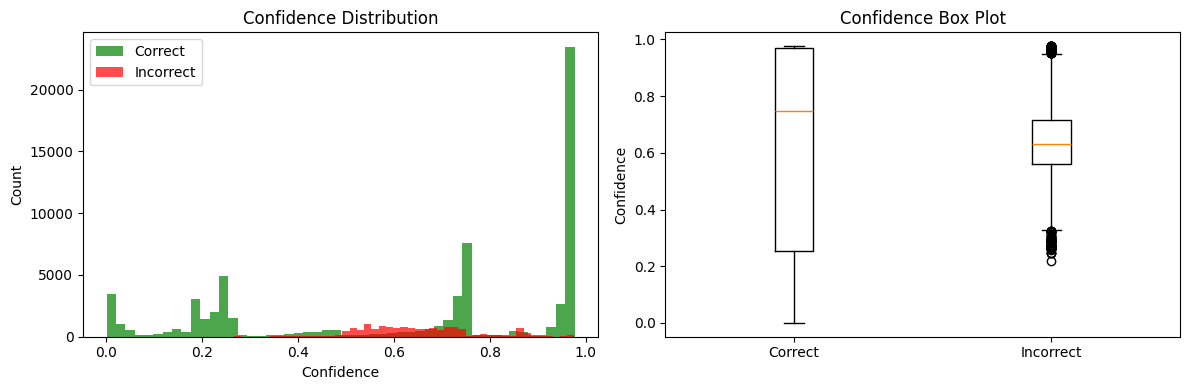

In [33]:
print("="*60)
print(" TEST 7: CONFIDENCE DISTRIBUTION")
print("="*60)

import matplotlib.pyplot as plt

# Separate correct and incorrect predictions
correct_indices = [i for i in range(len(all_preds)) if all_preds[i] == y_test[i]]
incorrect_indices = [i for i in range(len(all_preds)) if all_preds[i] != y_test[i]]

correct_conf = [all_probs[i] for i in correct_indices]
incorrect_conf = [all_probs[i] for i in incorrect_indices]

print(f"Correct predictions: {len(correct_conf):,}")
print(f"  Mean confidence: {np.mean(correct_conf):.4f}")
print(f"  Median confidence: {np.median(correct_conf):.4f}")

print(f"\nIncorrect predictions: {len(incorrect_conf):,}")
print(f"  Mean confidence: {np.mean(incorrect_conf):.4f}")
print(f"  Median confidence: {np.median(incorrect_conf):.4f}")

# Plot confidence distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(correct_conf, bins=50, alpha=0.7, color='green', label='Correct')
plt.hist(incorrect_conf, bins=50, alpha=0.7, color='red', label='Incorrect')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.title('Confidence Distribution')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([correct_conf, incorrect_conf], labels=['Correct', 'Incorrect'])
plt.ylabel('Confidence')
plt.title('Confidence Box Plot')

plt.tight_layout()
plt.savefig('results/UNSW/confidence_distribution.png', dpi=150)
plt.show()

In [34]:
print("="*60)
print(" TEST 2: THRESHOLD OPTIMIZATION")
print("="*60)

thresholds = [0.3, 0.4, 0.49, 0.5, 0.6, 0.7, 0.8, 0.9]
threshold_results = []

for thresh in thresholds:
    preds_thresh = [1 if p >= thresh else 0 for p in all_probs]
    p = precision_score(y_test, preds_thresh)
    r = recall_score(y_test, preds_thresh)
    f = f1_score(y_test, preds_thresh)
    threshold_results.append({'threshold': thresh, 'precision': p, 'recall': r, 'f1': f})
    
    print(f"Threshold {thresh}: Precision={p:.4f}, Recall={r:.4f}, F1={f:.4f}")

# Find best F1
best = max(threshold_results, key=lambda x: x['f1'])
print(f"\n Best threshold for F1: {best['threshold']} (F1={best['f1']:.4f})")

 TEST 2: THRESHOLD OPTIMIZATION
Threshold 0.3: Precision=0.7275, Recall=0.9989, F1=0.8419
Threshold 0.4: Precision=0.7348, Recall=0.9957, F1=0.8456
Threshold 0.49: Precision=0.7589, Recall=0.9867, F1=0.8579
Threshold 0.5: Precision=0.7626, Recall=0.9855, F1=0.8598
Threshold 0.6: Precision=0.8303, Recall=0.9631, F1=0.8917
Threshold 0.7: Precision=0.9012, Recall=0.9032, F1=0.9022
Threshold 0.8: Precision=0.9434, Recall=0.6239, F1=0.7511
Threshold 0.9: Precision=0.9891, Recall=0.5956, F1=0.7435

 Best threshold for F1: 0.7 (F1=0.9022)


In [35]:
print("="*60)
print(" TEST 8: FINAL SUMMARY STATISTICS")
print("="*60)

print(f"\n OVERALL PERFORMANCE:")
print(f"   Test Samples: {len(y_test):,}")
print(f"   Attacks Detected: {tp:,}/{tp+fn:,} ({recall*100:.2f}%)")
print(f"   Normal Correct: {tn:,}/{tn+fp:,} ({tn/(tn+fp)*100:.2f}%)")
print(f"   False Positives: {fp:,} ({fp/(fp+tn)*100:.2f}% of normal)")
print(f"   False Negatives: {fn:,} ({fn/(tp+fn)*100:.2f}% of attacks)")

print(f"\n BEST ATTACK TYPES (Detection >95%):")
best_attacks = [a for a in attack_results if a['rate'] > 95]
for a in best_attacks:
    print(f"   {a['attack']}: {a['rate']:.2f}% ({a['detected']}/{a['total']})")

print(f"\n WORST ATTACK TYPES (Detection <80%):")
worst_attacks = [a for a in attack_results if a['rate'] < 80]
for a in worst_attacks:
    print(f"   {a['attack']}: {a['rate']:.2f}% ({a['detected']}/{a['total']})")

 TEST 8: FINAL SUMMARY STATISTICS

 OVERALL PERFORMANCE:
   Test Samples: 82,332
   Attacks Detected: 44,728/45,332 (98.67%)
   Normal Correct: 22,787/37,000 (61.59%)
   False Positives: 14,213 (38.41% of normal)
   False Negatives: 604 (1.33% of attacks)

 BEST ATTACK TYPES (Detection >95%):
   Analysis: 98.67% (668/677)
   Backdoor: 100.00% (583/583)
   DoS: 99.54% (4070/4089)
   Exploits: 99.01% (11022/11132)
   Generic: 99.98% (18868/18871)
   Reconnaissance: 99.40% (3475/3496)
   Shellcode: 99.21% (375/378)
   Worms: 100.00% (44/44)

 WORST ATTACK TYPES (Detection <80%):
